## Customer Segmentation Using K-Means Clustering

### Project Overview
This project applies **unsupervised machine learning** to perform customer segmentation
on mall customer data. Using the **K-Means clustering algorithm**, customers are grouped
into distinct segments based on their **annual income** and **spending behavior**,
enabling data-driven marketing strategies.

---

### Objective
- Identify natural customer segments without labeled data using **K-Means clustering**
- Determine the optimal number of clusters using the **Elbow Method** and **Silhouette Score**
- Derive actionable business insights from each customer segment

---

### Outcome
The model successfully segments customers into **5 distinct groups**, each representing
a unique spending pattern. These segments can help businesses:
- Design **targeted marketing campaigns** per customer group
- Prioritize **high-value customers** for retention strategies
- Tailor **product recommendations** based on income and spending behavior

In [ ]:
##importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler




In [ ]:
#importing dataset
from google.colab import  files
uploaded=files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
#loading dataset to dataframe
df=pd.read_csv("Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
#renaming mistyped  Genre column to Gender
df = df.rename(columns={'Genre': 'Gender'})

In [ ]:
df.shape

(200, 5)

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
## checking for missing values
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
##Statistical summary
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


##  Observations

### CustomerID
- Used only as a unique identifier — **dropped before modeling.**

### Gender
- Categorical feature with 2 values: **Male** and **Female**
- Excluded from clustering — binary encoding distorts
  Euclidean distance in KMeans

### Age
- **Mean:** 38.85 years | **Std:** 13.97 | **Range:** 18–70
- Diverse age distribution — **will be evaluated** for clustering

### Annual Income (k$)
- **Mean:** 60.56 | **Std:** 26.26 | **Range:** 15–137
- Wide variation in income levels — **strong clustering candidate**

### Spending Score (1–100)
- **Mean:** 50.20 | **Std:** 25.82 | **Range:** 1–99
- Significant variation in spending behavior — **strong clustering candidate**

### Key Observations
- No missing values across any feature
- Features exist on different scales → **StandardScaler applied before clustering**
- Gender excluded from clustering (categorical)
- Age, Annual Income and Spending Score evaluated as clustering features

In [ ]:
# Dropping CustomerID
df = df.drop('CustomerID', axis=1)


In [ ]:

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


##EDA

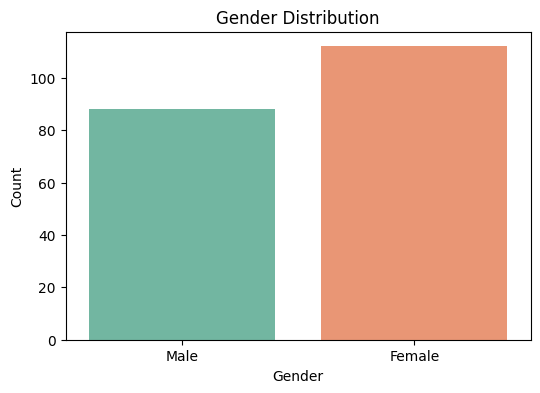

In [ ]:
# Gender Distribution
plt.figure(figsize=(6, 4))
# Fix for the warning
sns.countplot(x='Gender', data=df, hue='Gender', palette='Set2', legend=False)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Gender Distribution

- Dataset contains **112 Female** and **88 Male** customers
- Slight female majority (~56% Female, ~44% Male)
- Gender is **not used as a clustering feature** as  encoding
  distorts Euclidean distance in KMeans

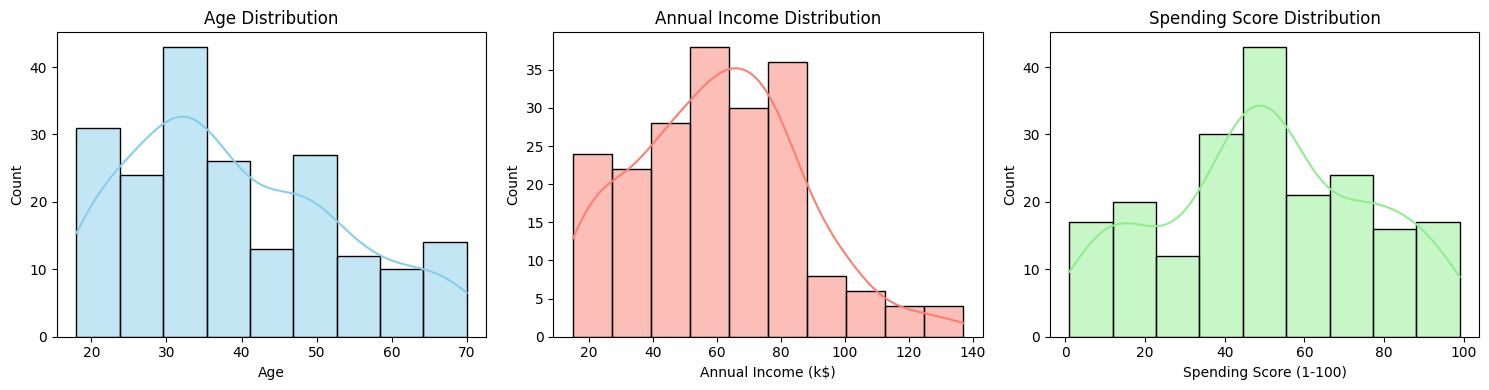

In [ ]:
# Distribution of Numerical Features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

### Feature Distributions

**Age Distribution**
- **Right-skewed** — majority of customers are between **25–35 years**
- Tail extends towards older age groups (60–70)
- Few older customers in the dataset

**Annual Income Distribution**
- **Right-skewed** — most customers earn between **40k$–80k$**
- Tail extends towards higher income (100k$–140k$)
- Few high-income customers present

**Spending Score Distribution**
- **Roughly normal** — centered around **40–50**
- Customers spend fairly evenly across all score ranges
- Spending behavior is **not driven by income alone**

### Key Takeaway
- No strong linear relationship between features →
  **unsupervised clustering is the right approach**
- After StandardScaler, features will have equal variance →
  KMeans can form **meaningful spherical clusters**
- Labels unavailable → confirms **unsupervised learning**

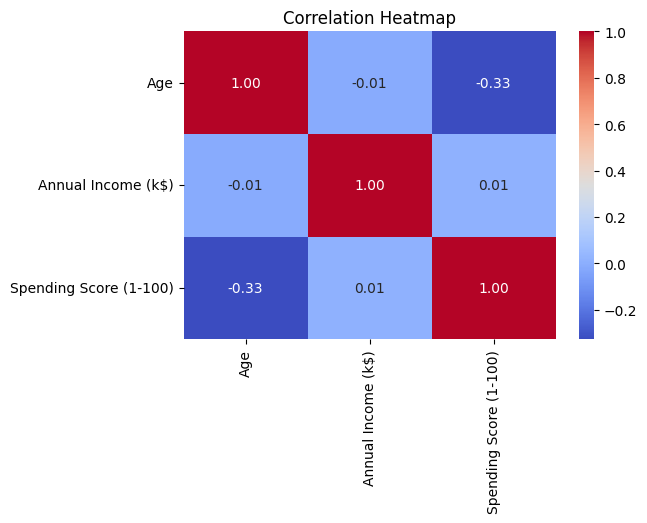

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Correlation Heatmap

| Feature Pair | Correlation | Interpretation |
|---|---|---|
| Age vs Annual Income | -0.01 | No relationship |
| Age vs Spending Score | -0.33 | Weak negative — older customers tend to spend less |
| Annual Income vs Spending Score | 0.01 | No relationship |

### Key Observations
- **No strong correlation** exists between any feature pair
- Annual Income and Spending Score are **nearly independent** (0.01)
- Age has a **weak negative correlation** with Spending Score (-0.33)
  — older customers slightly tend to spend less
- Absence of strong correlations confirms that **patterns cannot be
  captured by linear methods** → validates use of clustering

### Why This Matters for Clustering
- Independent features mean each feature contributes
  **unique information** to the clusters
- No multicollinearity issues — KMeans will not be
  dominated by any single feature after scaling

### Feature Selection

For clustering, the following features are considered:

| Feature | Type | Include? | Reason |
|---|---|---|---|
| Annual Income (k$) | Numerical | ✅ Yes | Directly represents purchasing power |
| Spending Score (1-100) | Numerical | ✅ Yes | Directly represents spending behavior |
| Age | Numerical | 🔄 To Evaluate | Weak negative correlation (-0.33) with Spending Score — may reveal young vs old spender patterns |
| Gender | Categorical | ❌ No | Binary encoding distorts Euclidean distance in KMeans |

**Gender** is excluded because KMeans relies on Euclidean distance —
encoding Gender as 0/1 does not carry meaningful distance information
and may distort cluster boundaries.

**Age** is evaluated separately — correlation heatmap shows a weak
negative relationship (-0.33) with Spending Score, suggesting older
customers tend to spend less. Both feature sets are compared using
Silhouette Score to make a data-driven decision.

In [ ]:
# Feature Selection - Option 1 (2 features)
X_2 = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Feature Selection - Option 2 (3 features)
X_3 = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling both
scaler = StandardScaler()
X_2_scaled = scaler.fit_transform(X_2)
X_3_scaled = scaler.fit_transform(X_3)

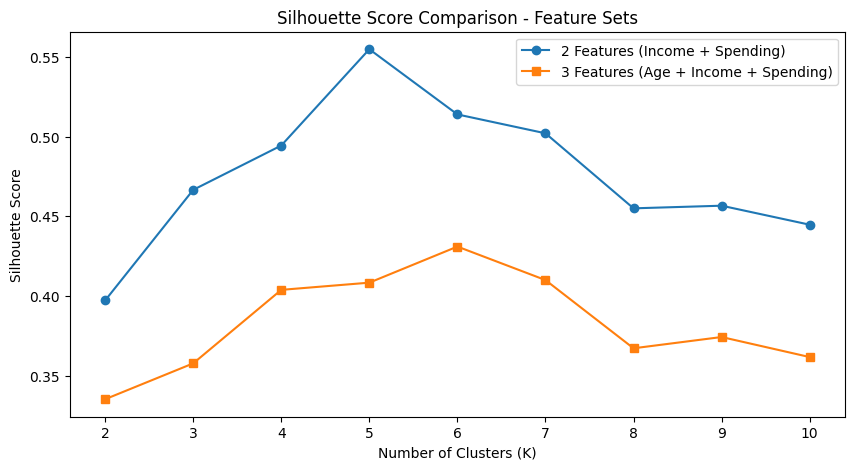

Best Silhouette Score (2 features): 0.5547 at K=5
Best Silhouette Score (3 features): 0.4311 at K=6


In [ ]:
# Comparing  Silhouette Scores for both feature sets
from sklearn.metrics import silhouette_score

silhouette_2 = []
silhouette_3 = []

for k in range(2, 11):
    # 2 features
    km_2 = KMeans(n_clusters=k, random_state=42)
    labels_2 = km_2.fit_predict(X_2_scaled)
    silhouette_2.append(silhouette_score(X_2_scaled, labels_2))

    # 3 features
    km_3 = KMeans(n_clusters=k, random_state=42)
    labels_3 = km_3.fit_predict(X_3_scaled)
    silhouette_3.append(silhouette_score(X_3_scaled, labels_3))

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouette_2, marker='o', label='2 Features (Income + Spending)')
plt.plot(range(2, 11), silhouette_3, marker='s', label='3 Features (Age + Income + Spending)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Comparison - Feature Sets')
plt.legend()
plt.show()

print(f"Best Silhouette Score (2 features): {max(silhouette_2):.4f} at K={silhouette_2.index(max(silhouette_2))+2}")
print(f"Best Silhouette Score (3 features): {max(silhouette_3):.4f} at K={silhouette_3.index(max(silhouette_3))+2}")

### Feature Selection - Decision

| Feature Set | Best Silhouette Score | Best K |
|---|---|---|
| Income + Spending Score | **0.5547** | **5** |
| Age + Income + Spending Score | 0.4311 | 6 |

**Decision: 2 Features (Income + Spending Score) selected.**

Adding Age actually **reduces clustering quality** (0.5547 → 0.4311)
because:
- Age has only weak correlation (-0.33) with Spending Score
- It introduces noise into Euclidean distance calculation
- Clean 2D cluster boundaries get distorted in 3D space

**Final feature set:**
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

**Preliminary K = 5**

In [ ]:
# Final Feature Set
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## Optimal K Selection

We use two methods to validate and cross-confirm K=5:
- **Elbow Method** — finds K where WCSS stops decreasing sharply
- **Silhouette Score** — finds K where clusters are most well-separated

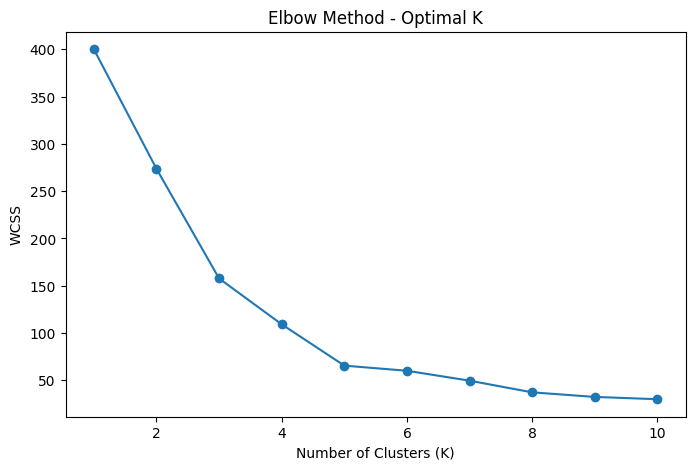

In [ ]:
##elbow method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method - Optimal K')
plt.show()

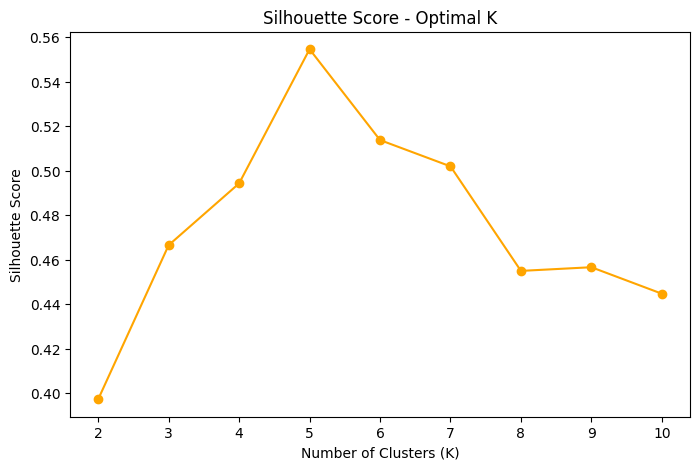

Best Silhouette Score: 0.5547 at K=5


In [ ]:
##silhouette scores
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - Optimal K')
plt.show()

print(f"Best Silhouette Score: {max(silhouette_scores):.4f} at K={silhouette_scores.index(max(silhouette_scores))+2}")

### Optimal K - Decision

| Method | Result | Optimal K |
|---|---|---|
| Elbow Method | Clear elbow — WCSS flattens after K=5 | **K=5**  |
| Silhouette Score | Highest score 0.5547 at K=5 | **K=5**  |

**Both methods independently confirm K=5.**

This dual validation confirms our preliminary selection —
K=5 is not arbitrary but **statistically and visually justified.**

Final model will be built with **K=5.**

In [ ]:
##applying k means with optimal k
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

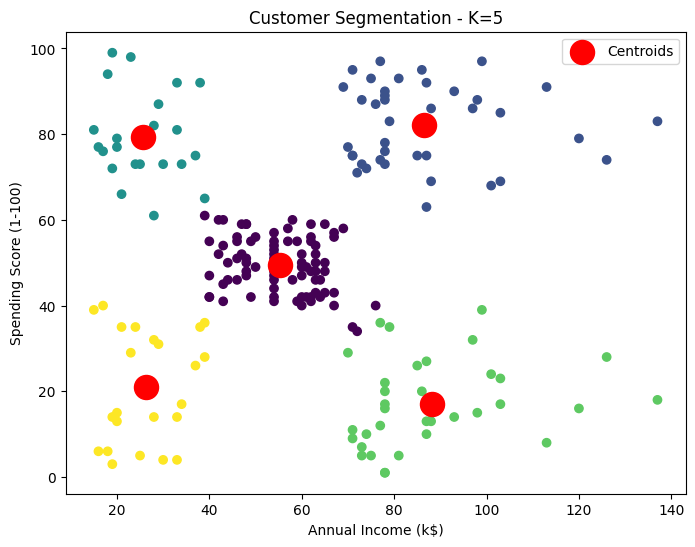

In [ ]:
#visualizing the cluster
# Inverse transform centroids back to original scale
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1],
            c=clusters, cmap='viridis')
plt.scatter(centroids_original[:, 0],
            centroids_original[:, 1],
            s=300, c='red', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation - K=5')
plt.legend()
plt.show()

In [ ]:
##cluster profile table
cluster_profile = df.groupby('Cluster')[['Age',
                                          'Annual Income (k$)',
                                          'Spending Score (1-100)']].mean().round(2)
cluster_profile['Count'] = df.groupby('Cluster')['Cluster'].count()
print(cluster_profile)

           Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                          
0        42.72               55.30                   49.52     81
1        32.69               86.54                   82.13     39
2        25.27               25.73                   79.36     22
3        41.11               88.20                   17.11     35
4        45.22               26.30                   20.91     23


## Cluster Analysis & Business Insights

### Cluster Profile Table

| Cluster | Avg Age | Avg Income (k$) | Avg Spending Score | Count |
|---|---|---|---|---|
| 0 | 42.72 | 55.30 | 49.52 | 81 |
| 1 | 32.69 | 86.54 | 82.13 | 39 |
| 2 | 25.27 | 25.73 | 79.36 | 22 |
| 3 | 41.11 | 88.20 | 17.11 | 35 |
| 4 | 45.22 | 26.30 | 20.91 | 23 |

**Note:** Age was not used as a clustering feature but is included
as descriptive insight — reveals average age composition of each
cluster formed by Income + Spending Score.

---

### Cluster Interpretations

**Cluster 0 — Average Income, Average Spending (81 customers)**
- Middle-aged customers (~43 years)
- Moderate income and moderate spending
- Largest segment — represents the typical customer
- **Strategy:** Loyalty programs and seasonal promotions
  to increase engagement

**Cluster 1 — High Income, High Spending (39 customers)**
- Youngest high-value customers (~33 years)
- High income (86k$) and high spending (82/100)
- Most valuable segment for the business
- **Strategy:** Premium memberships, exclusive offers,
  retention programs

**Cluster 2 — Low Income, High Spending (22 customers)**
- Youngest segment (~25 years)
- Low income (25k$) but high spending (79/100)
- Impulsive or trend-driven spenders
- **Strategy:** Limited-time offers, instalment payment
  options, trend-based promotions

**Cluster 3 — High Income, Low Spending (35 customers)**
- Middle-aged customers (~41 years)
- High income (88k$) but very low spending (17/100)
- Conservative spenders despite high earning power
- **Strategy:** Personalized discounts, premium product
  exposure, loyalty rewards to unlock spending potential

**Cluster 4 — Low Income, Low Spending (23 customers)**
- Oldest segment (~45 years)
- Low income (26k$) and low spending (21/100)
- Budget-conscious customers
- **Strategy:** Budget-friendly products, value deals,
  cost-effective promotions

## Conclusion

This project successfully segmented 200 mall customers into
**5 distinct groups** using K-Means clustering.

### Key Findings
| Cluster | Segment | Income | Spending |
|---|---|---|---|
| 0 | Average Customers | Medium | Medium |
| 1 | High Value | High | High |
| 2 | Young Impulsive Spenders | Low | High |
| 3 | Conservative High Earners | High | Low |
| 4 | Budget Customers | Low | Low |

### What Was Done Right
- EDA performed before modeling
- Feature selection validated using Silhouette Score
- Optimal K confirmed by **two independent methods**
  (Elbow + Silhouette)
- Business insights derived from **actual cluster statistics**
  not assumptions

### Silhouette Score: 0.5547
Indicates **well-separated, meaningful clusters** —
confirms the model is reliable for business decision-making.